Execute a preparação antes da aula. Ela baixa a mesma imagem da praça e as
funções de visualização do repositório público. Este notebook funciona sozinho,
em CPU, com as bibliotecas disponíveis no Colab.

No primeiro notebook, interpretamos as caixas, classes e scores de um detector.
Agora vamos acompanhar **como uma imagem se transforma em mapas dentro de uma rede**.

In [1]:
from urllib.request import urlretrieve
base = "https://raw.githubusercontent.com/carlosfab/bootcamp-visao-computacional-drones/d14ab59106ac51dd56fd0bab0ac89f2475156197/"
urlretrieve(base + "dados/aula-02/praca-sintetica.png", "praca.png")
urlretrieve(base + "apoio/aula02_mapas.py", "apoio_mapas.py");

In [2]:
import torch
from torch import nn
from torch.nn import functional as F

In [3]:
from PIL import Image
from torchvision.transforms.functional import pil_to_tensor, rgb_to_grayscale
from apoio_mapas import mostrar, matriz, mapas, comparar, convolucao

**Como a rede recebe a imagem?**

Vamos usar uma cópia de 384 × 256 pixels para manter as operações leves.
A cena é sintética, gerada por IA para a demonstração.

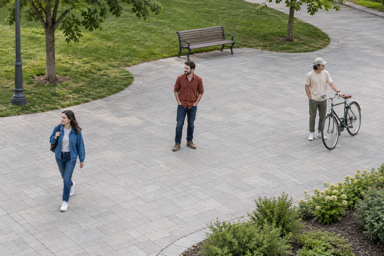

In [4]:
foto = Image.open("praca.png").convert("RGB").resize((384, 256))
foto

In [5]:
imagem = pil_to_tensor(foto).float() / 255
imagem.shape, imagem.dtype

(torch.Size([3, 256, 384]), torch.float32)

O tensor está em `[C, H, W]`: três canais, 256 linhas e 384 colunas.
Dividir por 255 coloca os valores de intensidade entre 0 e 1.

Para enxergar uma operação por vez, vamos trabalhar com **um canal em tons de cinza**.
A conversão combina R, G e B com pesos de luminância; ela não escolhe apenas um canal.

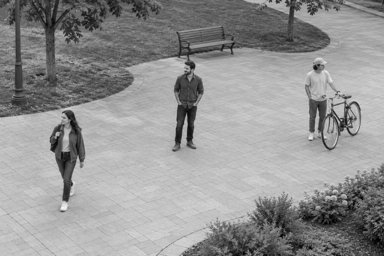

In [6]:
cinza = rgb_to_grayscale(imagem)
mostrar(cinza)

In [7]:
entrada = cinza.unsqueeze(0)
entrada.shape

torch.Size([1, 1, 256, 384])

`unsqueeze(0)` acrescentou o eixo do lote: `[N, C, H, W]`.
Temos **uma imagem, um canal, 256 linhas e 384 colunas**.
Adicionar esse eixo não duplica a imagem.

O detector anterior recebia uma lista de imagens. Aqui estamos chamando uma
camada convolucional diretamente e usaremos um tensor com o eixo de batch explícito.

**O que um filtro faz com a imagem?**

Um filtro, ou kernel, contém pesos que serão combinados com uma região da entrada.
Vamos escolher os pesos abaixo. A coluna da direita soma; a da esquerda subtrai.
Assim, o filtro responde a mudanças de intensidade da esquerda para a direita,
realçando principalmente **bordas verticais**.

In [8]:
filtro = torch.tensor([[-1., 0., 1.],
                       [-1., 0., 1.],
                       [-1., 0., 1.]])

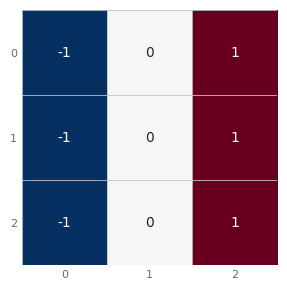

In [9]:
matriz(filtro)

`F.conv2d` recebe os pesos no formato
`[canais de saída, canais de entrada, altura, largura]`, neste caso `[1, 1, 3, 3]`.
`reshape` organiza os mesmos nove números nesse formato.

In [10]:
pesos = filtro.reshape(1, 1, 3, 3)
bordas = F.conv2d(entrada, pesos)
bordas.shape

torch.Size([1, 1, 254, 382])

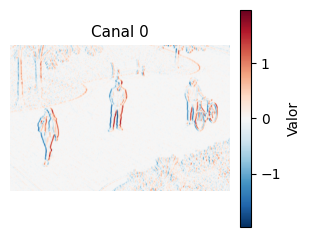

In [11]:
mapas(bordas)

O resultado tem valores positivos e negativos. O sinal indica o sentido da mudança;
o módulo indica a intensidade da resposta ao filtro. A barra de cores mostra essa escala.
Este é um **mapa de resposta a um filtro escolhido por nós**.

Aqui usamos passo 1, sem padding e sem bias. O filtro precisa caber inteiramente
na imagem: por isso, `256 × 384` virou `254 × 382`.

**De onde vem cada número desse mapa?**

Vamos ampliar um recorte de 6 × 6 pixels perto da pessoa do centro.
Arredondaremos **apenas esse recorte** para uma casa decimal, para facilitar a conta.
Essa é uma simplificação didática; a imagem usada acima conserva seus valores.

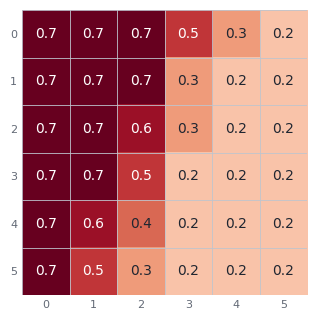

In [12]:
recorte = cinza[0, 80:86, 173:179].round(decimals=1)
matriz(recorte)

Na primeira posição, o filtro cobre as três primeiras linhas e colunas.
`*` multiplica elemento por elemento. Observe os nove produtos antes de somar.

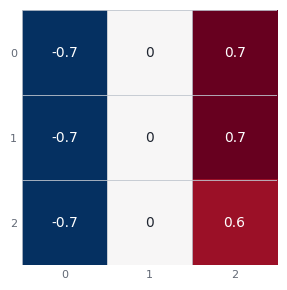

In [13]:
regiao = recorte[:3, :3]
produtos = regiao * filtro
matriz(produtos)

In [14]:
valor = produtos.sum()
valor

tensor(-0.1000)

Essa soma preenche **uma posição da saída**. Deslocamos o filtro uma coluna e
repetimos a conta, sempre com os mesmos pesos.

Na animação, avance quadro a quadro: a janela destaca os pixels usados; o painel
central mostra as multiplicações; o painel da direita recebe a soma. As posições
que ainda não foram calculadas ficam vazias.

In [15]:
convolucao(recorte, filtro)

Agora vamos conferir o mapa completo com o PyTorch. Um recorte de `6 × 6`, com
filtro `3 × 3`, passo 1 e sem padding, permite quatro posições por eixo: saída `4 × 4`.

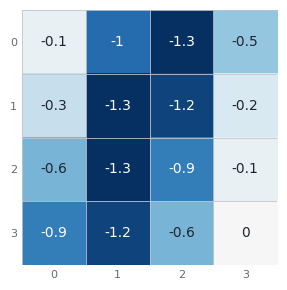

In [16]:
entrada_pequena = recorte.reshape(1, 1, 6, 6)
saida_pequena = F.conv2d(entrada_pequena, pesos)
matriz(saida_pequena[0, 0])

Compare a primeira posição do mapa com a soma manual. Escolha outra posição
na animação e refaça a conta com lápis ou uma célula adicional.

Na terminologia matemática, o PyTorch faz **correlação cruzada**: aplica o filtro
na orientação em que o escrevemos, sem invertê-lo. Em redes neurais, essa operação
é usualmente chamada de convolução.

Essa janela calcula respostas locais usando os mesmos pesos em todas as posições.
As janelas do notebook anterior ilustravam a busca por regiões para uma possível
classificação. Aqui acompanhamos a operação dentro de uma camada.

**Por que uma camada produz vários mapas?**

Vamos criar uma camada com um canal de entrada e **quatro filtros**.
Cada filtro produzirá um canal de saída. `nn.Conv2d` guarda esses pesos como
parâmetros que poderão ser ajustados durante um treinamento.

`padding=1` acrescenta uma borda de zeros. Com filtro `3 × 3` e passo 1, isso
preserva altura e largura. Usaremos `bias=False` para manter a conta de produto
e soma; com bias, haveria também um valor adicional por canal de saída.

In [17]:
torch.manual_seed(42)
conv = nn.Conv2d(1, 4, 3, padding=1, bias=False)
conv.weight.shape

torch.Size([4, 1, 3, 3])

Agora os pesos têm formato `[4, 1, 3, 3]`: quatro filtros, cada um com nove pesos.
A semente torna a inicialização repetível no mesmo ambiente.
Os valores abaixo foram inicializados aleatoriamente; **a camada ainda não foi treinada**.

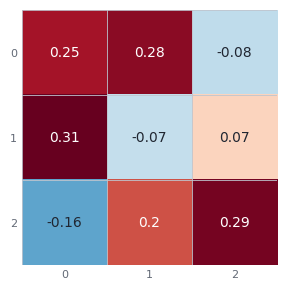

In [18]:
matriz(conv.weight[0, 0])

In [19]:
respostas = conv(entrada)
respostas.shape

torch.Size([1, 4, 256, 384])

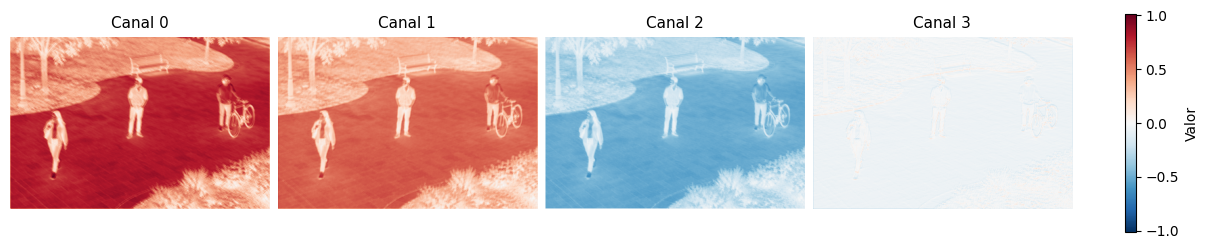

In [20]:
mapas(respostas)

Temos quatro mapas porque aplicamos quatro filtros diferentes. Aqui, nenhum
canal significa automaticamente “pessoa”, “bicicleta” ou outra classe.
As cores representam valores, e os mapas usam a mesma escala.

Até uma camada aleatória transforma a imagem. Para que os pesos se tornem úteis
para uma tarefa, será preciso ajustá-los com dados e um objetivo de treinamento.

**O que a ReLU faz?**

A ReLU mantém valores positivos e transforma os negativos em zero.
Vamos observar primeiro essa regra em quatro números.

In [21]:
relu = nn.ReLU()
valores = torch.tensor([-2., -0.5, 0., 3.])
relu(valores)

tensor([0., 0., 0., 3.])

Aplicaremos a mesma regra a todas as posições de todos os mapas.
Compare o quarto canal, de índice `3`, usando a mesma escala antes e depois.

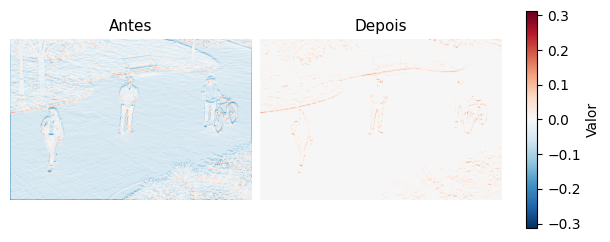

In [22]:
ativacoes = relu(respostas)
comparar(respostas[0, 3], ativacoes[0, 3])

A ReLU não muda as dimensões do tensor e não tem pesos para aprender.
Ela introduz uma **não linearidade**: a resposta para valores negativos passa
a seguir uma regra diferente da resposta para positivos. Ao intercalar esse tipo
de operação com camadas de pesos, a rede pode representar relações mais complexas.

Zerar um valor negativo é uma regra numérica; não é uma decisão de que aquela
região da imagem é “irrelevante”.

**Como os mapas ficam menores?**

Um exemplo é o max pooling: em cada região, conservamos o maior valor.
`MaxPool2d(2)` usa regiões `2 × 2` e, por padrão, passo 2.
Qual valor deve sair deste exemplo?

In [23]:
pool = nn.MaxPool2d(2)
amostra = torch.tensor([[1., 3.], [2., 4.]])
pool(amostra.reshape(1, 1, 2, 2))

tensor([[[[4.]]]])

In [24]:
reduzidos = pool(ativacoes)
ativacoes.shape, reduzidos.shape

(torch.Size([1, 4, 256, 384]), torch.Size([1, 4, 128, 192]))

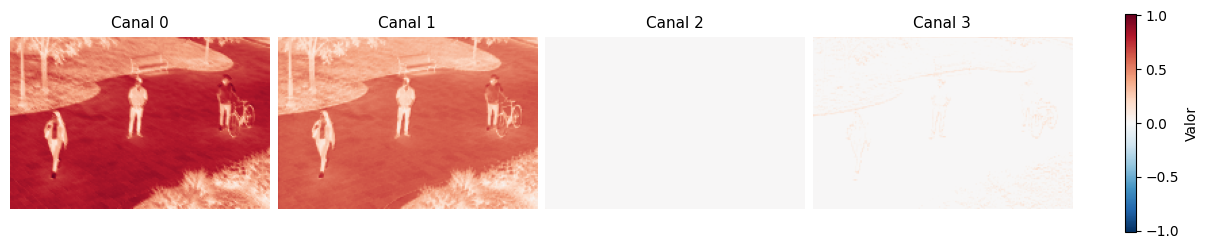

In [25]:
mapas(reduzidos)

Batch e canais continuam iguais. A altura passou de 256 para 128, e a largura,
de 384 para 192. O pooling atua separadamente em cada canal.

As figuras são ampliadas para facilitar a leitura; o tamanho do desenho na tela
não representa a quantidade de posições do tensor. Confira sempre o `shape`.
Reduzir a resolução espacial descarta detalhes — uma questão relevante quando
um objeto ocupa poucos pixels em uma imagem de drone.

**Como essas operações viram um bloco de rede?**

Vamos reunir **as mesmas camadas que já criamos**, na mesma ordem.
`nn.Sequential` passa a saída de uma operação como entrada da próxima.

In [26]:
rede = nn.Sequential(conv, relu, pool)
rede

Sequential(
  (0): Conv2d(1, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
)

In [27]:
saida = rede(entrada)
saida.shape

torch.Size([1, 4, 128, 192])

O percurso foi:

| Operação | Formato da saída |
|---|---|
| Entrada em tons de cinza | `[1, 1, 256, 384]` |
| Convolução: quatro filtros | `[1, 4, 256, 384]` |
| ReLU | `[1, 4, 256, 384]` |
| Pooling: regiões e passo 2 | `[1, 4, 128, 192]` |

Esse bloco produz mapas. Para produzir classes ou caixas, uma rede precisa de
componentes adicionais, escolhidos e treinados para essa tarefa.

Experimentos curtos, um por vez:

- Transponha o filtro manual com `filtro.T` na célula que cria `pesos` e execute
  novamente a aplicação à imagem. Que orientação de borda ficou mais evidente?
- Mude os quatro filtros da camada para oito e execute novamente a partir da
  criação de `conv`. O que muda no shape? Isso significa oito classes?
- Em uma célula adicional, crie `pool = nn.MaxPool2d(4)`. Execute novamente a partir
  de `reduzidos = pool(ativacoes)`, incluindo a criação de `rede`. O que acontece
  com a resolução dos mapas? A amostra de `2 × 2` não comporta uma janela de `4 × 4`.

Ao terminar, restaure os valores originais e execute tudo em ordem.

Escolhemos um filtro manualmente e observamos pesos aleatórios em uma camada.
**Como a rede aprende quais pesos usar?** Essa será a pergunta do próximo notebook.

Referências para consulta:

- [PyTorch: tensores](https://docs.pytorch.org/tutorials/beginner/basics/tensorqs_tutorial.html)
- [PyTorch: Conv2d, formatos e operação](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
- [PyTorch: convolução com pesos fornecidos](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.conv2d.html)
- [PyTorch: ReLU](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
- [PyTorch: MaxPool2d](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)
- [PyTorch: composição de camadas](https://docs.pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html#nn-sequential)
- [Matplotlib: animação incorporada em HTML](https://matplotlib.org/stable/api/_as_gen/matplotlib.animation.Animation.html#matplotlib.animation.Animation.to_jshtml)